In [14]:
import os,pickle,re

import numpy as np
import pandas as pd
from sklearn.metrics import f1_score,make_scorer,precision_score,recall_score
import shap

from project_package.visualization import Model_Visualizer
from project_package import evaluation,modeling

In [15]:
# choose to test either full version or lite version
use_lite_version = False
if use_lite_version:
    base_directory = 'supervised_lite'
else:
    base_directory = 'supervised'

# setting
recalculate_evaluation = False

#### Problem 1: Classification (booking completion vs cancellation)

In [16]:
# based on the f1 macro metric on evaluation set, random forest model was chosen.
family_report = pd.read_csv(f'{base_directory}/cls_all_models_metrics_rf_report.csv')
family_report

,model,accuracy,precision_macro,recall_macro,f1_macro,best_params,cv_mean,cv_std,roc_auc
0,logreg,0.761552,0.747269,0.751146,0.748978,{'clf__C': 0.1},0.746211,0.005649,0.858148
1,rf,0.934352,0.946245,0.916820,0.928174,"{'clf__max_depth': 11, 'clf__min_samples_leaf'...",0.930493,0.004182,0.965743
2,knn,0.759847,0.745593,0.749998,0.747489,"{'clf__n_neighbors': 15, 'clf__weights': 'dist...",0.728861,0.005054,0.835600


In [17]:
files = os.listdir(base_directory)

file = [item for item in files if 'target_completed_.pkl' in item][-1]

model_path = os.path.join(base_directory, file)

with open(model_path, "rb") as f:
    model = pickle.load(f)
model

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000001EEC6DA03D0>),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x000001EED096CD30>)])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced', max_depth=11,
                                        min_samples_leaf=3, n_estimators=300,
                                        n_jobs=-1, random_state=42))])

Load the train and test data

In [ ]:
split_df = pd.read_csv(os.path.join(base_directory, 'split_assignments_classification.csv'),
                       on_bad_lines='skip'
                       )

if use_lite_version:
    model_data =pd.read_csv('datasets/processed/ncr_ride_bookings_with_weather_filled_scaled_short___target_completed___top20_s30.csv')
else:
    model_data =pd.read_csv('datasets/processed/ncr_ride_bookings_with_weather_filled_scaled_short.csv')

In [19]:
feature_cols = [re.sub(r'^num__', '', name) for name in model[0].get_feature_names_out()]
feature_cols = [re.sub(r'cat__', '', name) for name in feature_cols]
get_cols = ['_target_completed_'] + feature_cols

if use_lite_version:
    # train data
    train_split = split_df.loc[split_df.split=='train'][['Booking ID','Customer ID']]
    train_data = model_data.merge(train_split,on=['Booking ID','Customer ID'])
    y_train = train_data['_target_completed_']
    train_data = modeling.drop_unnecessary_cols(train_data)
    # validation data
    test_split = split_df.loc[split_df.split=='valid'][['Booking ID','Customer ID']]
    test_data = model_data.merge(test_split,on=['Booking ID','Customer ID'])
    y_test = test_data['_target_completed_']
    test_data = modeling.drop_unnecessary_cols(test_data)
else:
    # train data
    train_split = split_df.loc[split_df.split=='train'][['Booking ID','Customer ID']]
    train_data = model_data.merge(train_split,on=['Booking ID','Customer ID'])
    train_data = modeling.make_binary_target(train_data)[0]
    y_train = train_data['_target_completed_']
    train_data = modeling.drop_unnecessary_cols(train_data)
    # validation data
    test_split = split_df.loc[split_df.split=='valid'][['Booking ID','Customer ID']]
    test_data = model_data.merge(test_split,on=['Booking ID','Customer ID'])
    test_data = modeling.make_binary_target(test_data)[0]
    y_test = test_data['_target_completed_']
    test_data = modeling.drop_unnecessary_cols(test_data)

train_data = train_data[get_cols]
test_data = test_data[get_cols]

In [20]:
prediction_df = pd.read_csv(f'{base_directory}/cls_best_rf_preds.csv')

# check model metric score
print('---------on training dataset--------------')
print('precision from model:',precision_score(y_train,model.predict(train_data)))
print('precision from model(macro):',precision_score(y_train,model.predict(train_data),average='macro'))
print()
print('recall from model:',recall_score(y_train,model.predict(train_data)))
print('recall from model(macro):',recall_score(y_train,model.predict(train_data),average='macro'))

print()
print('---------on test dataset--------------')
print('precision from model:',precision_score(y_test,model.predict(test_data)))
print('precision from model(macro):',precision_score(y_test,model.predict(test_data),average='macro'))
print('precision from file:',precision_score(prediction_df.y_true,prediction_df.y_pred))
print('precision from file(macro):',precision_score(prediction_df.y_true,prediction_df.y_pred,average='macro'))
print()
print('recall from model:',recall_score(y_test,model.predict(test_data)))
print('recall from model(macro):',recall_score(y_test,model.predict(test_data),average='macro'))
print('recall from file:',recall_score(prediction_df.y_true,prediction_df.y_pred))
print('recall from file(macro):',recall_score(prediction_df.y_true,prediction_df.y_pred,average='macro'))

---------on training dataset--------------
precision from model: 0.9144838603342039
precision from model(macro): 0.9496671585816059

recall from model: 0.9919957090398976
recall from model(macro): 0.9203473385935244

---------on test dataset--------------
precision from model: 0.9118958354443206
precision from model(macro): 0.9462452573152745
precision from file: 0.9118958354443206
precision from file(macro): 0.9462452573152745

recall from model: 0.9897717899367611
recall from model(macro): 0.9168198148821891
recall from file: 0.9897717899367611
recall from file(macro): 0.9168198148821891


In [21]:
# create visualization object

classify_vis_obj = Model_Visualizer(
    train_data,
    test_data,
    y_train,
    y_test,
    feature_names = feature_cols,
    target_name='_target_completed_'
    )

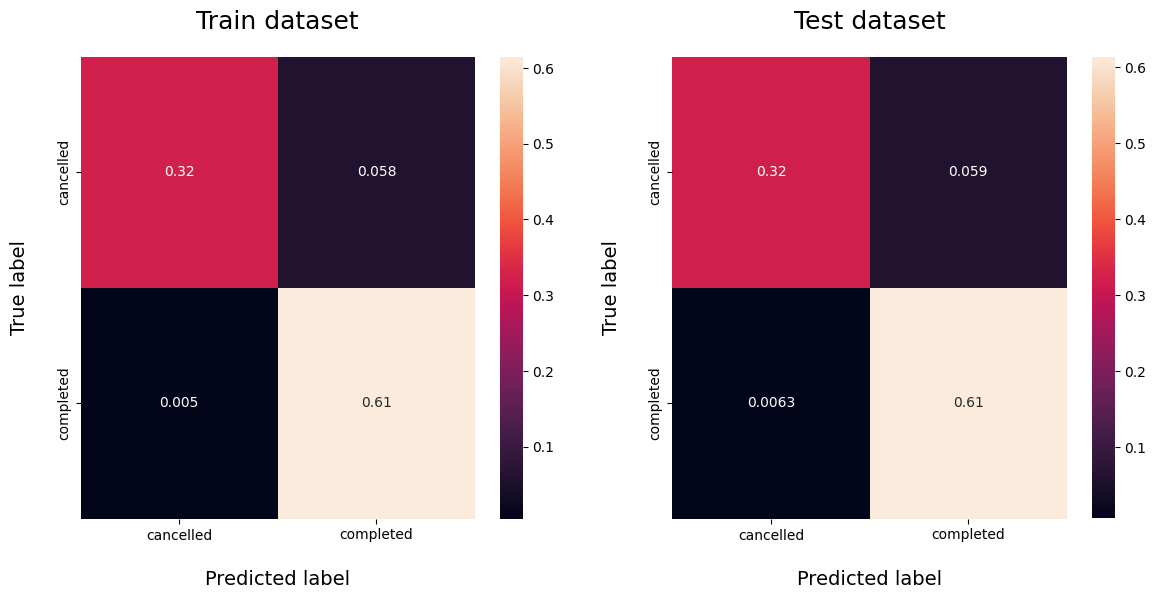

In [22]:
# confusion matrix
classify_vis_obj.confusion_matrix(model,['cancelled','completed'],normalize=True)

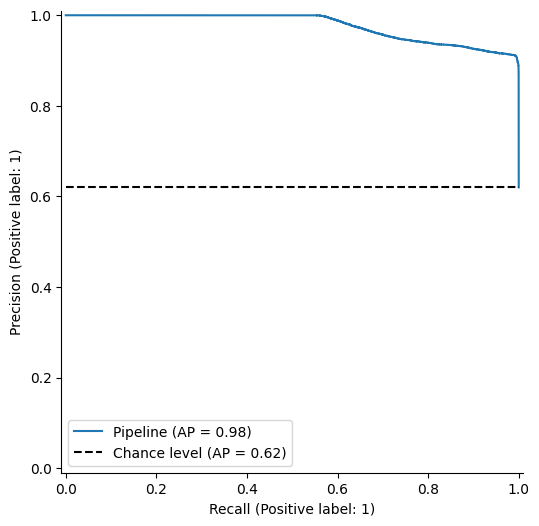

In [23]:
#precision curve
classify_vis_obj.precision_recall_curve(model)

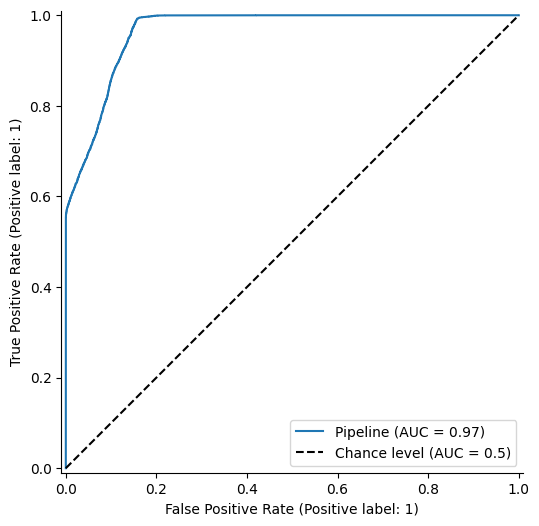

In [24]:
#ROC curve
classify_vis_obj.ROC_curve(model)

Feature Importance and Ablation Analysis

<Axes: title={'center': 'Figure 1: Booking completion - Feature importance plot'}, xlabel='Importance', ylabel='Features'>

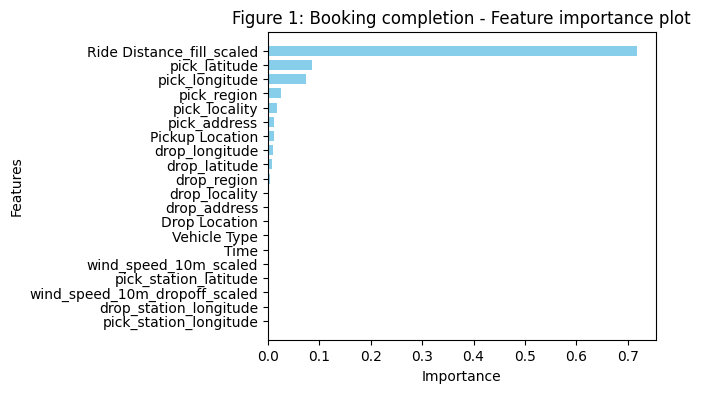

In [25]:
classify_vis_obj.feature_importance_plot(model.named_steps['clf'].feature_importances_,normalize=False,top_n=20,
                                         title='Figure 1: Booking completion - Feature importance plot',
                                         figsize=(5,4))

In [26]:
try:
    os.makedirs(f'{base_directory}/evaluation', exist_ok=True)

    if not recalculate_evaluation:
        with open(base_directory + "/evaluation/booking_cancel_permutation_train_result.pkl", "rb") as f:
            train_permute = pickle.load(f)
        with open(base_directory + "/evaluation/booking_cancel_permutation_test_result.pkl", "rb") as f:
            test_permute = pickle.load(f)
    else:
        raise Exception('Recalculating permutation test')
except:
    train_permute,test_permute = evaluation.permutation_test(
        model,train_data,test_data,
        target_col = '_target_completed_',scorer='f1_macro',random_state=0,n_jobs=-1
    )

    with open(base_directory + "/evaluation/booking_cancel_permutation_train_result.pkl", "wb") as f:
        pickle.dump(train_permute, f)

    with open(base_directory + "/evaluation/booking_cancel_permutation_test_result.pkl", "wb") as f:
        pickle.dump(test_permute, f)

<Axes: title={'center': 'Figure 2: Booking completion - Permutation\n importance on train data'}, xlabel='Decrease in metric score'>

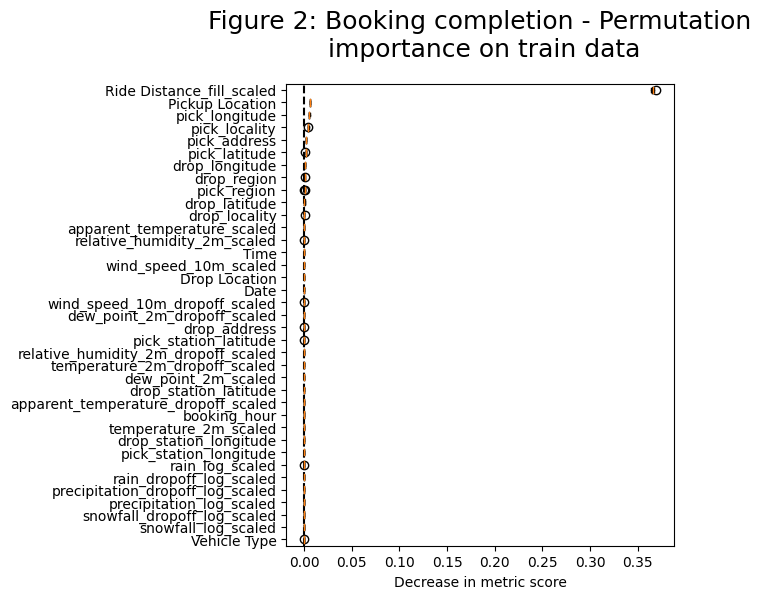

In [27]:
classify_vis_obj.permutation_importance_plot(train_permute,figsize=(5,6),title='Figure 2: Booking completion - Permutation\n importance on train data')

<Axes: title={'center': 'Booking completion: Permutation\n importance on test data'}, xlabel='Decrease in metric score'>

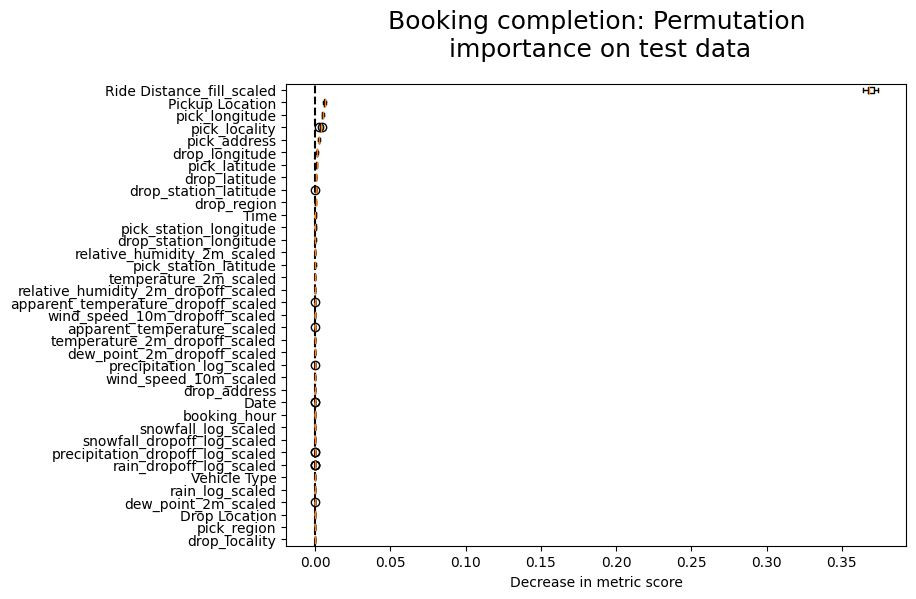

In [14]:
classify_vis_obj.permutation_importance_plot(test_permute,figsize=(8,6),title='Booking completion: Permutation\n importance on test data')

In [15]:
remove_features = [
    'pick_latitude',
    'pick_longitude',
    'pick_locality',
    'Pickup Location',
    'pick_address',
    'Ride Distance_fill_scaled',
    ['pick_latitude','pick_longitude','pick_locality','Pickup Location','pick_address'],
    ['pick_latitude','pick_longitude','pick_locality','Pickup Location','pick_address','Ride Distance_fill_scaled']
]

try:
    os.makedirs(f'{base_directory}/evaluation', exist_ok=True)
    if not recalculate_evaluation:
        score_array = np.load(base_directory + '/evaluation/booking_cancel_ablation_test.npy')
        eval_df = pd.read_csv(base_directory + '/evaluation/booking_cancel_ablation_test.csv')
    else:
        raise Exception('Recalculating ablation test')
except:

    score_array,eval_df = evaluation.ablation_test(
        model,
        train_data = train_data,
        test_data = test_data,
        target_col = '_target_completed_',
        scorer=make_scorer(f1_score,average='macro'),
        remove_features = remove_features,
        n_jobs=-1
    )

    np.save(base_directory + '/evaluation/booking_cancel_ablation_test.npy',score_array)
    eval_df.to_csv(base_directory + '/evaluation/booking_cancel_ablation_test.csv',index=False)

eval_df.head()

,remove_features,score_mean,score_std,score_test
0,none,0.929898,0.001487,0.931692
1,pick_latitude,0.926717,0.008365,0.928932
2,pick_longitude,0.929281,0.001049,0.928078
3,pick_locality,0.930110,0.001044,0.929089
4,Pickup Location,0.930081,0.001053,0.928389


<Axes: title={'center': 'Ablation test'}, xlabel='f1 score'>

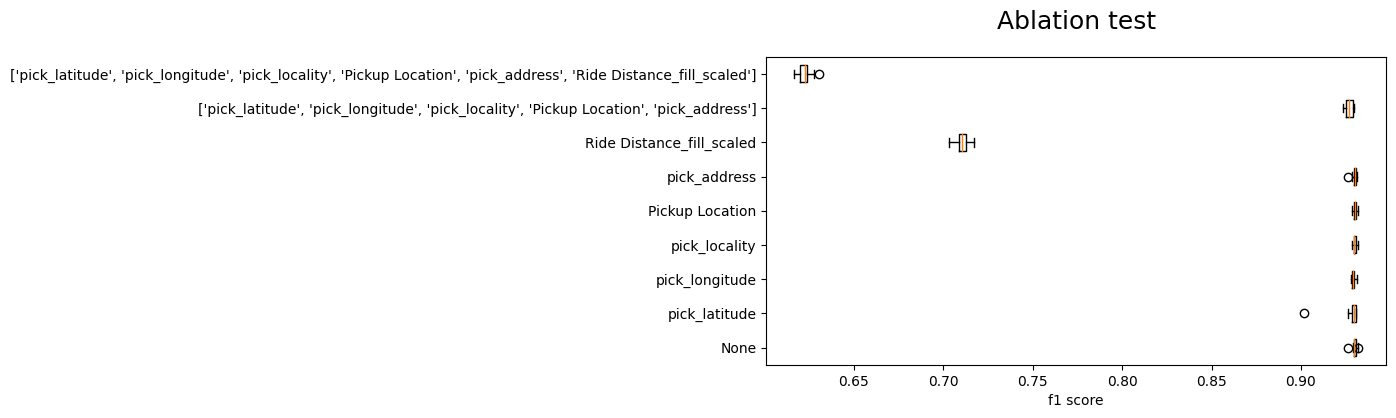

In [17]:
# Ablation test plot
classify_vis_obj.box_plot(score_array.T,labels=['None'] + remove_features,title='Ablation test',xlabel='f1 score')

Sensivity analysis

In [18]:
try:
    os.makedirs(f'{base_directory}/evaluation', exist_ok=True)
    if not recalculate_evaluation:
        eval_df = pd.read_csv(base_directory + '/evaluation/booking_cancel_sensivity_test.csv')
    else:
        raise Exception('Recalculating sensivity test')
except:
    grids = {
        'clf__n_estimators':np.linspace(100,1000,10).astype(int),
        'clf__max_depth':np.linspace(1,11,11).astype(int)
    }
    eval_df = evaluation.supervised_sensivity_test(
        model,train_data,
        target_col='_target_completed_',
        param_grid=grids,
        scoring = 'f1_macro',
        verbose=0,
        n_jobs=-1
    )
    eval_df.to_csv(base_directory + '/evaluation/booking_cancel_sensivity_test.csv',index=False)
eval_df.head()

,clf__max_depth,clf__n_estimators,f1_macro,f1_macro_std
0,1,100,0.757484,0.004124
1,1,200,0.753664,0.004027
2,1,300,0.754689,0.003909
3,1,400,0.754181,0.004759
4,1,500,0.753798,0.004282


In [19]:
plot_1_cond = eval_df.clf__max_depth.unique()[1]
plot_2_cond = eval_df.clf__n_estimators.unique()[2]
classify_vis_obj.sensivity_plot(eval_df,
               'f1_macro',
               param1 = ('clf__n_estimators','clf__max_depth',plot_1_cond),
               param2 = ('clf__max_depth','clf__n_estimators',plot_2_cond),
               subplot_titles = [
                   f'Sensivity vs. n_estimators (with max_depth={plot_1_cond})',
                   f'Sensivity vs. max_depth (with n_estimators={plot_2_cond})',
                   None
               ]
               )

Learning curve

In [28]:
try:
    os.makedirs(f'{base_directory}/evaluation', exist_ok=True)
    if not recalculate_evaluation:
        result_df = pd.read_csv(base_directory + '/evaluation/booking_cancel_learning_curve.csv')
    else:
        raise Exception('Recalculating learning curve')
except:
    _,_,result_df = evaluation.learning_curve_test(
        model,train_data,
        target_col='_target_completed_',
        sample_range=np.logspace(3,5,30).astype(int),
        scorer = make_scorer(f1_score,average='macro'),
        n_jobs=-1,
        random_state=0
    )

    result_df.to_csv(base_directory + '/evaluation/booking_cancel_learning_curve.csv',index=False)

result_df.head(5)

,n_sample,score_mean,score_std
0,1000,0.886505,0.035331
1,1172,0.894219,0.033319
2,1373,0.903474,0.020376
3,1610,0.909540,0.019191
4,1887,0.890574,0.017946


<Axes: title={'center': 'Figure 5: Booking completion - Learning curve analysis'}, xlabel='No. of training records', ylabel='F1 macro score'>

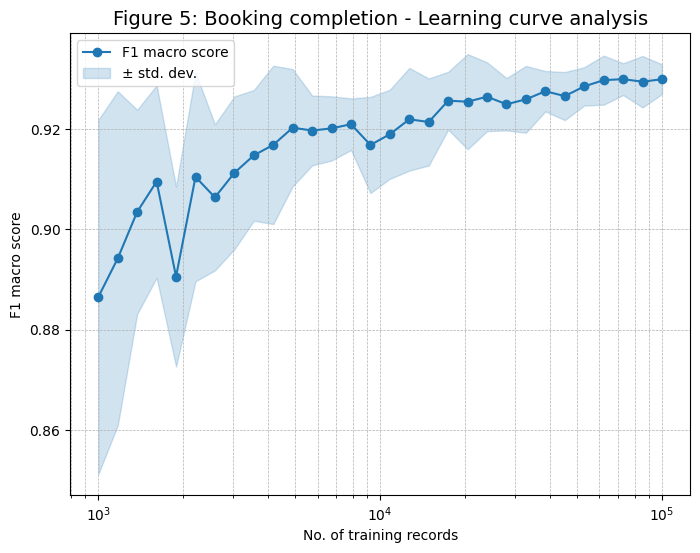

In [29]:
# Learning curve plot

classify_vis_obj.learning_curve_plot(
    np.logspace(3,5,30).astype(int),
    result_df.score_mean,
    result_df.score_std,
    log_sample=True,
    metric_label='F1 macro score',
    title = 'Figure 5: Booking completion - Learning curve analysis'
    )

Failure analysis (classification)

Edge case analysis


In [30]:
# Our dataset is very biased toward completion status because we have less records about cancellation in the dataset
print('---train dataset---')
print(train_data._target_completed_.value_counts())

print('---test dataset---')
print(test_data._target_completed_.value_counts())

---train dataset---
_target_completed_
1    72711
0    44580
Name: count, dtype: int64
---test dataset---
_target_completed_
1    18185
0    11138
Name: count, dtype: int64


In [31]:
# we choose to analyze failure records using Ride distance as this is the one with the highest impact on the model result
ride_statistics = train_data.describe()['Ride Distance_fill_scaled']
distance_mean = ride_statistics['mean']
distance_std = ride_statistics['std']
edge_cases = test_data.loc[
    (test_data['Ride Distance_fill_scaled']>=(distance_mean+2*distance_std))|(test_data['Ride Distance_fill_scaled']<=(distance_mean-2*distance_std))
              ]

# we have a very imbalance records between two label for edge cases
print('edge cases - label count:')
print(edge_cases._target_completed_.value_counts())

# add prediction
edge_pred_df = edge_cases[['_target_completed_']]
edge_pred_df['prediction'] = model.predict(edge_cases)

print('\n-----------------------')
print('edge cases wrong prediction:')
edge_pred_df[edge_pred_df['prediction'] != edge_pred_df['_target_completed_']]
# We can see that for all fail prediction in edge cases, the model predict all booking as potentially completion

edge cases - label count:
_target_completed_
1    874
0     47
Name: count, dtype: int64

-----------------------
edge cases wrong prediction:


,_target_completed_,prediction
509,0,1
829,0,1
1460,0,1
2012,0,1
3392,0,1
3751,0,1
4542,0,1
5117,0,1
5900,0,1
8686,0,1


In [32]:
# get wrong prediction examples from edge cases
edge_sample_df,edge_sample_info_df = evaluation.get_worst_examples(
    model,edge_cases,
    get_n=3,
    target_col='_target_completed_',
    problem_type='classification',
    get_random_err=False,
    random_state=0
)


# all edge case
edge_shap_values,_ = evaluation.shap_analysis(
    model,
    shap.TreeExplainer,
    train_df = shap.sample(train_data,nsamples=1000),  # recommended number in documentation
    test_df = shap.sample(edge_cases),
    target_col = '_target_completed_'
)

# edge case samples
edge_ex_shap_values,_ = evaluation.shap_analysis(
    model,
    shap.TreeExplainer,
    train_df = shap.sample(train_data,nsamples=1000),  # recommended number in documentation
    test_df = edge_sample_df,
    target_col = '_target_completed_'
)

edge_sample_info_df

 91%|==================  | 182/200 [00:12<00:01]       

,true_label,predicted_label,probability_0,probability_1
15909,0,1,0.351659,0.648341
11473,0,1,0.368135,0.631865
27059,0,1,0.377409,0.622591
25751,0,1,0.477527,0.522473
21144,0,1,0.493367,0.506633
3751,0,1,0.498739,0.501261


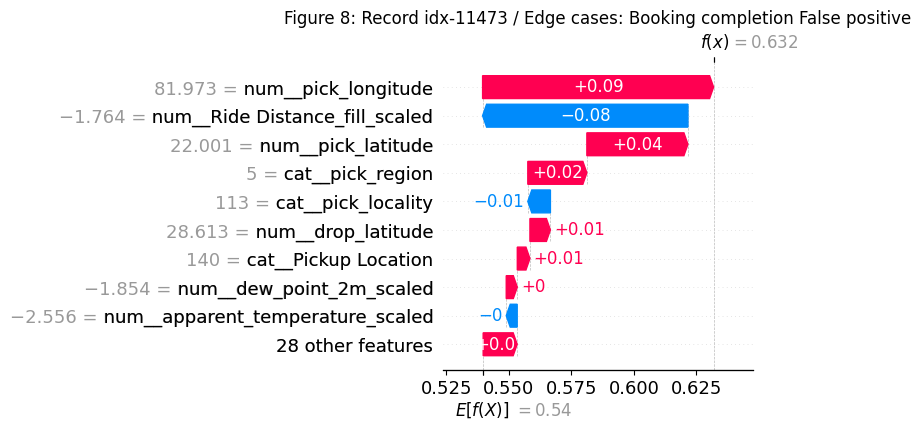

In [33]:
classify_vis_obj.waterfall_plot(
    edge_ex_shap_values[:,:,1][1],
    title = f'Figure 8: Record idx-{edge_sample_info_df.index[1]} / Edge cases: Booking completion False positive',
    figsize=(4,4)
)

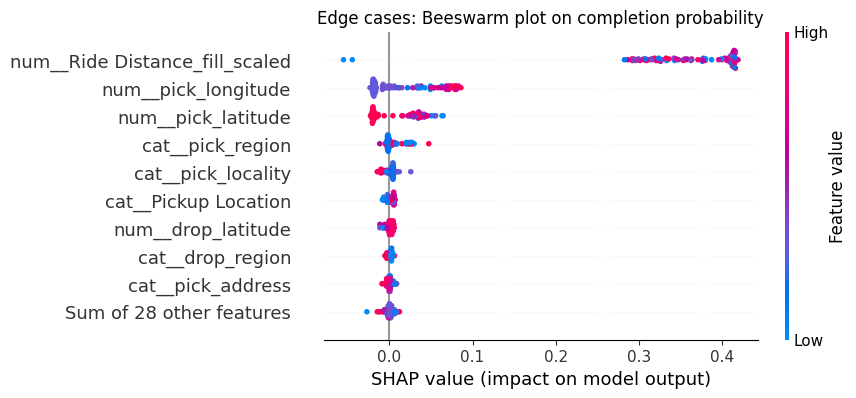

In [34]:
classify_vis_obj.beeswarm_plot(
    edge_shap_values[:,:,1],
    title = 'Edge cases: Beeswarm plot on completion probability',
    figsize=(7,4)
    )

Test dataset analysis

In [35]:
# get worst examples of False Positive and False Negative on test dataset
ex_df,ex_info_df = evaluation.get_worst_examples(
    model,test_data,
    get_n=1,
    target_col='_target_completed_',
    problem_type='classification',
    get_random_err=False,
    random_state=0
)

test_shap_values,_ = evaluation.shap_analysis(
    model,
    shap.TreeExplainer,
    train_df = shap.sample(train_data,nsamples=1000), # recommended number in documentation
    test_df = shap.sample(test_data),
    target_col = '_target_completed_'
)

ex_shap_values,_ = evaluation.shap_analysis(
    model,
    shap.TreeExplainer,
    train_df = shap.sample(train_data,nsamples=1000),  # recommended number in documentation
    test_df = ex_df,
    target_col = '_target_completed_'
)
ex_info_df

 97%|=================== | 193/200 [00:14<00:00]       

,true_label,predicted_label,probability_0,probability_1
22181,0,1,0.195786,0.804214
25402,0,1,0.499859,0.500141
11931,1,0,0.500159,0.499841
11973,1,0,0.873574,0.126426


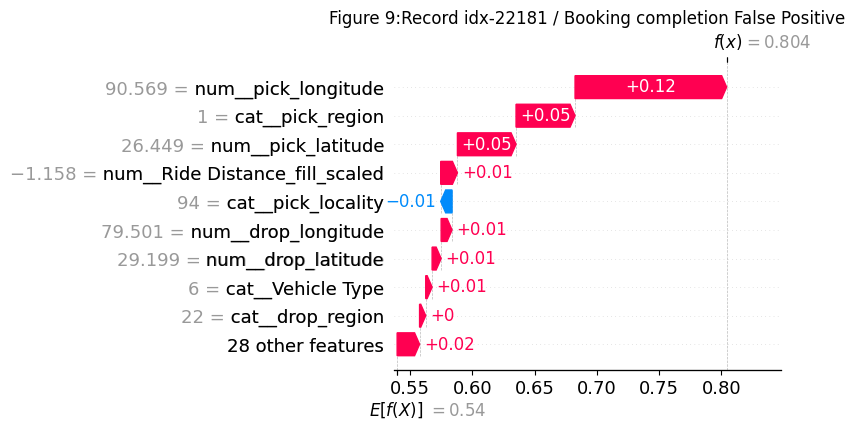

In [36]:
classify_vis_obj.waterfall_plot(
    ex_shap_values[:,:,1][0],
    title = f'Figure 9:Record idx-{ex_info_df.index[0]} / Booking completion False Positive',
    figsize=(5,4)
    )

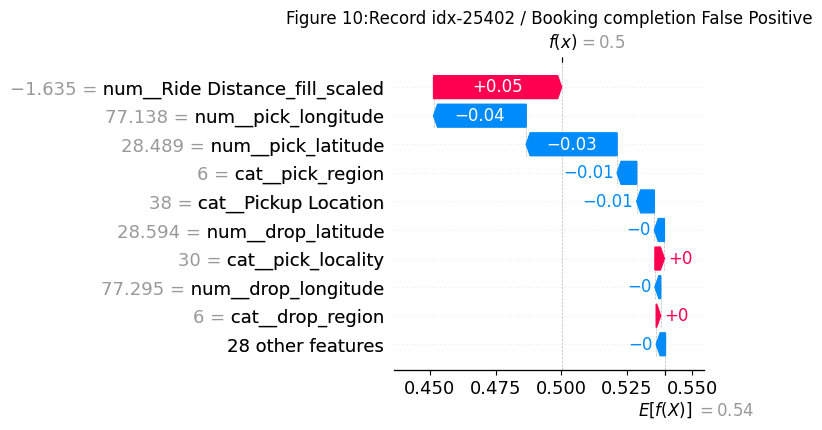

In [37]:
classify_vis_obj.waterfall_plot(
    ex_shap_values[:,:,1][1],
    title = f'Figure 10:Record idx-{ex_info_df.index[1]} / Booking completion False Positive',
    figsize=(4,4)
    )

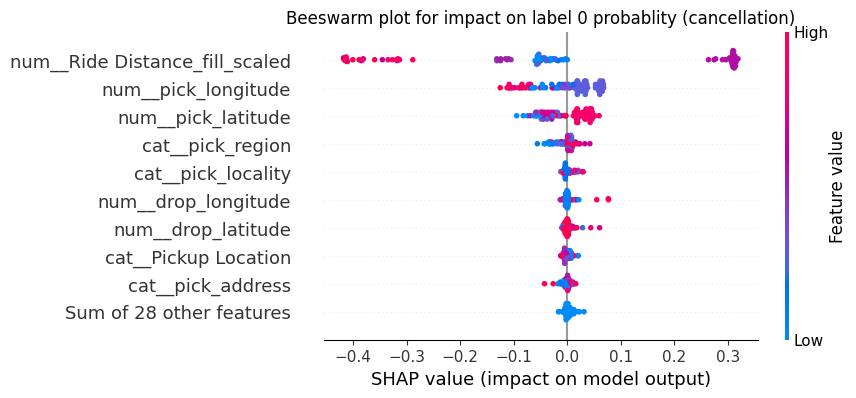

In [25]:
classify_vis_obj.beeswarm_plot(
    test_shap_values[:,:,0],
    title = 'Beeswarm plot for impact on label 0 probablity (cancellation)',
    figsize=(7,4)
    )

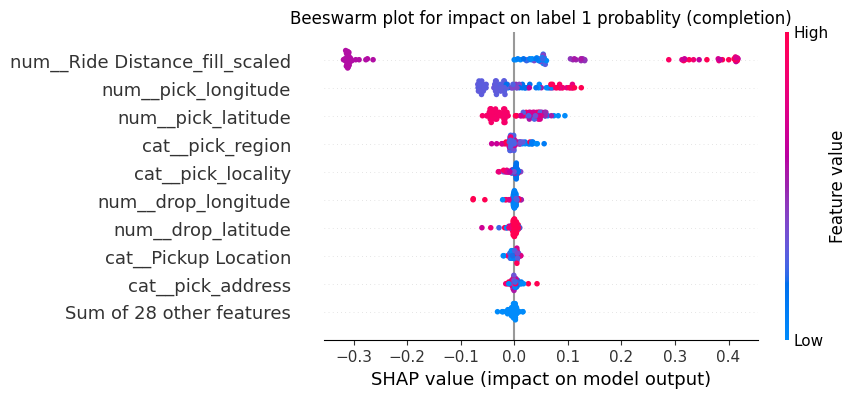

In [26]:
classify_vis_obj.beeswarm_plot(
    test_shap_values[:,:,1],
    title = 'Beeswarm plot for impact on label 1 probablity (completion)',
    figsize=(7,4)
    )